## Task Description 
In this task, a Logistic Regression model is applied to the Titanic Dataset to predict whether a passenger survived or not based on various personal and travel-related features.

Titanic Dataset: https://www.kaggle.com/datasets/yasserh/titanic-dataset
Logistic Regression is used to model the relationship between passenger attributes and the binary survival outcome. The dataset is preprocessed including handling missing values and encoding categorical variables then split into training and testing sets. The model’s performance is evaluated using classification metrics such as accuracy, precision, recall, and F1-score, along with a confusion matrix to analyze predictive results.

## Overall,
this task demonstrates a complete binary classification workflow, including data preprocessing, model training, evaluation, and result interpretation using pandas, NumPy, scikit-learn, and visualization libraries such as matplotlib or seaborn, where appropriate.

## Submission Requirements 
Students are required to submit the following:
- Source Code File
- A Python file (.py) or a Jupyter Notebook (.ipynb).

## download data

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\moust\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


## import libraries

In [5]:
import pandas as pd
import os 
from sklearn.preprocessing import OneHotEncoder
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
warnings.filterwarnings('ignore')

## read data

In [8]:
os.listdir(path)

['Titanic-Dataset.csv']

In [9]:
data=pd.read_csv(path+'/Titanic-Dataset.csv')

In [10]:
data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## data preprocessing

In [12]:
data.shape

(891, 12)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [14]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
data.Cabin.value_counts()

Cabin
B96 B98        4
G6             4
C23 C25 C27    4
C22 C26        3
F33            3
              ..
E34            1
C7             1
C54            1
E36            1
C148           1
Name: count, Length: 147, dtype: int64

In [16]:
data.Cabin.unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [17]:
data.drop('Cabin',axis=1,inplace=True)

In [18]:
data.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [19]:
data[data['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN


In [20]:
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

In [21]:
data['Age'] = data['Age'].fillna(data.groupby('Pclass')['Age'].transform('mean'))

In [22]:
data.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [24]:
data.drop('Name',axis=1,inplace=True)

In [25]:
data['Sex']=data['Sex'].map({'male':0,'female':1})

In [26]:
data.Sex.value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [27]:
data.drop('Ticket',axis=1,inplace=True)

In [28]:
data.Embarked.value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [29]:
encoder = OneHotEncoder(drop='first', sparse_output=False)

embarked_encoded = encoder.fit_transform(data[['Embarked']])

In [30]:
embarked_df = pd.DataFrame(embarked_encoded, columns=encoder.get_feature_names_out(['Embarked']))

data = data.drop('Embarked', axis=1)
data = pd.concat([data, embarked_df], axis=1)

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked_Q   891 non-null    float64
 9   Embarked_S   891 non-null    float64
dtypes: float64(4), int64(6)
memory usage: 69.7 KB


In [32]:
data.Survived.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

## data splitting

In [34]:
x=data.drop('Survived',axis=1)
y=data.Survived

In [35]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [36]:
model=LogisticRegression()

In [37]:
model.fit(xtrain,ytrain)

LogisticRegression()

In [38]:
model.score(xtrain,ytrain)

0.8033707865168539

In [39]:
model.score(xtest,ytest)

0.7988826815642458

In [40]:
accuracy_score(ytest,model.predict(xtest))

0.7988826815642458

In [41]:
precision_score(ytest,model.predict(xtest))

0.7794117647058824

In [42]:
recall_score(ytest,model.predict(xtest))

0.7162162162162162

In [43]:
f1_score(ytest,model.predict(xtest))

0.7464788732394366

In [44]:
cm=confusion_matrix(ytest,model.predict(xtest))

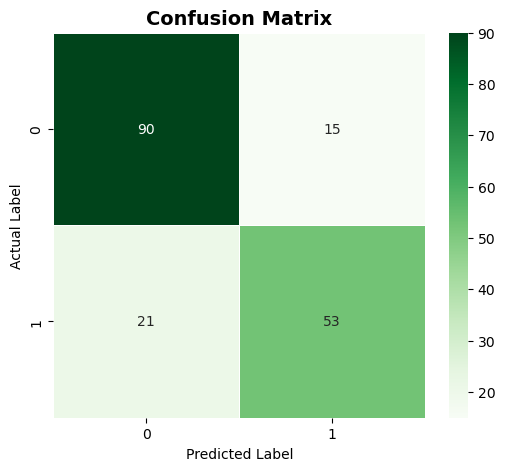

In [95]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, 
            annot=True, 
            fmt="d", 
            cmap="Greens",
            linewidths=0.5,
            linecolor="white")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix", fontsize=14, weight="bold")

plt.show()